In [44]:
import paramClassSheared
import numpy as np
import matplotlib.pyplot as plt

pList = paramClassSheared.generate()

In [29]:
def load_binary(varName,p):
    filePath = p.dirPath + varName + "_" + p.tStamp
    X = np.memmap(filePath, dtype="single", mode="r",shape=(p.Nx,p.Ny,p.Nz), order="F")
    return X[:-2,:,:] #Chop off two rows of zeros

def compute_chi(p):
    
    dx = p.Lx/p.Nx
    dy = p.Ly/p.Ny
    dz = p.Lz/p.Nz
        
    #Load in density and compute gradients
    r = load_binary("r", p)
    rx = np.gradient(r,dx,axis=0)
    ry = np.gradient(r,dx,axis=1)
    rz = np.gradient(r,dz,axis=2)

    chi = -p.kinV/(p.dGrad*p.Pr) * (rx**2+ry**2+rz**2)
    
    return chi

def plot_slice(fig, ax, Z, cmap, vmin, vmax):
    
    I = ax.imshow(Z.T, origin="lower", cmap = cmap, vmin = vmin, vmax = vmax)
    c = fig.colorbar(I, ax=ax, orientation='horizontal', location="top", anchor=(0.5,0.0), fraction=0.05)
    
    

In [22]:
#Load in simulation
p = pList["R1P1"]

In [23]:
u = load_binary("u",p)
v = load_binary("v",p)
w = load_binary("w",p)
r = load_binary("r",p)

chi = compute_chi(p)

In [39]:
r.max()

0.0009088013

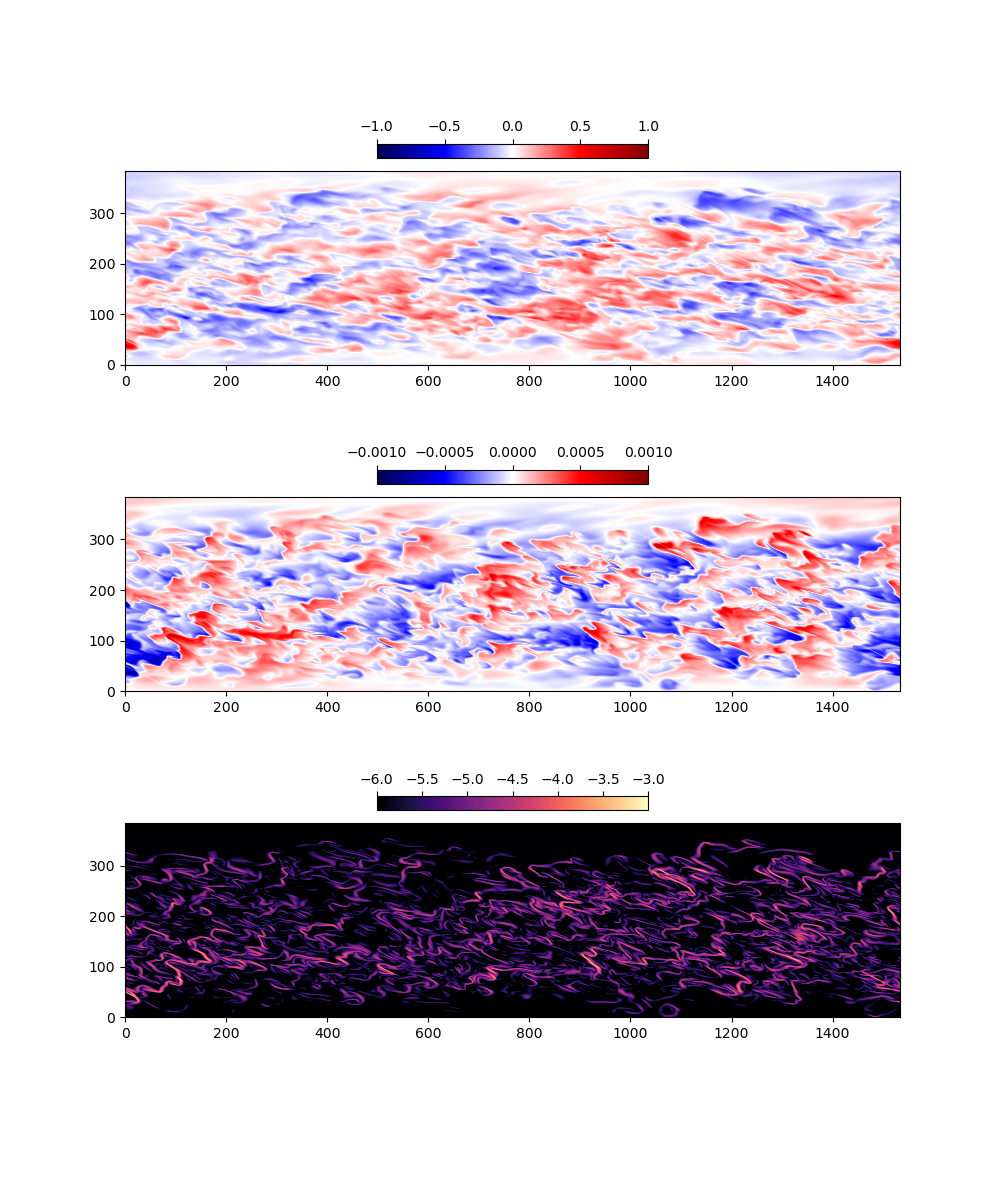

In [43]:
%matplotlib widget
fig, ax = plt.subplots(3,1,figsize=(10,12))

yIdx = 50

plot_slice(fig=fig, ax=ax[0], Z=u[:,yIdx,:], cmap="seismic", vmin=-1, vmax=1)
plot_slice(fig=fig, ax=ax[1], Z=r[:,yIdx,:], cmap="seismic", vmin=-0.001, vmax=0.001)
plot_slice(fig=fig, ax=ax[2], Z=np.log10(chi[:,yIdx,:]), cmap="magma", vmin=-6, vmax=-3)